In [1]:
import argparse
import os
from typing import Tuple, List

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def read_image_gray(path: str) -> np.ndarray:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {path}")
    if img.dtype != np.uint8:
        img = np.clip(img, 0, 255).astype(np.uint8)
    return img

def normalize_to_uint8(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    mn, mx = np.min(x), np.max(x)
    if mx - mn < 1e-12:
        return np.zeros_like(x, dtype=np.uint8)
    y = (x - mn) / (mx - mn) * 255.0
    return y.astype(np.uint8)

In [3]:
def plot_histogram(img: np.ndarray, title: str):
    plt.figure()
    plt.hist(img.ravel(), bins=256, range=(0, 255))
    plt.title(title)
    plt.xlabel("Intensity")
    plt.ylabel("Count")
    plt.show()
    plt.close()

#### (1)

Image shape: (389, 256), dtype: uint8


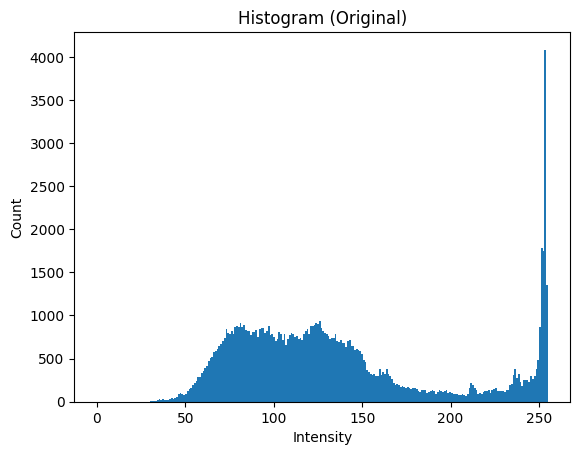

In [4]:
img_path = "../src/data/The_dress_blueblackwhitegold.jpg"
img = read_image_gray(img_path)
print(f"Image shape: {img.shape}, dtype: {img.dtype}")
plot_histogram(img, "Histogram (Original)")

##### Gamma correction

In [5]:
def gamma_correction(img: np.ndarray, gamma: float) -> np.ndarray:
    assert gamma > 0, "gamma must be > 0"
    lut = np.array([((i / 255.0) ** gamma) * 255.0 for i in range(256)], dtype=np.float32)
    out = cv2.LUT(img, lut.astype(np.uint8))
    return out

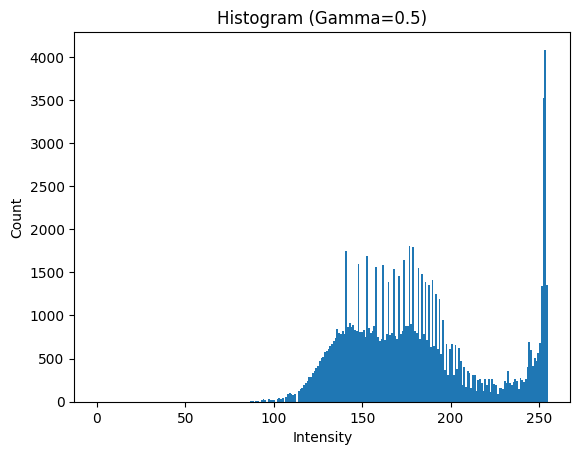

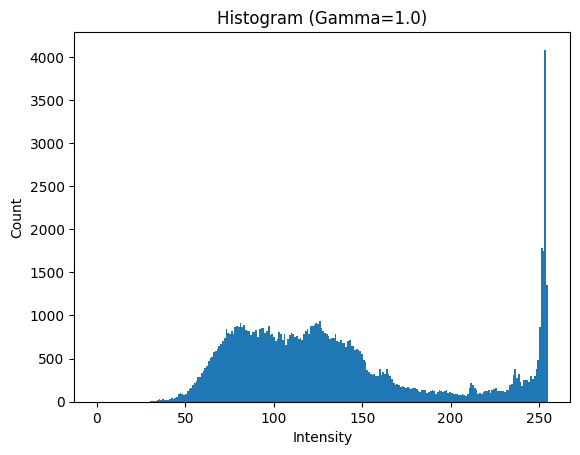

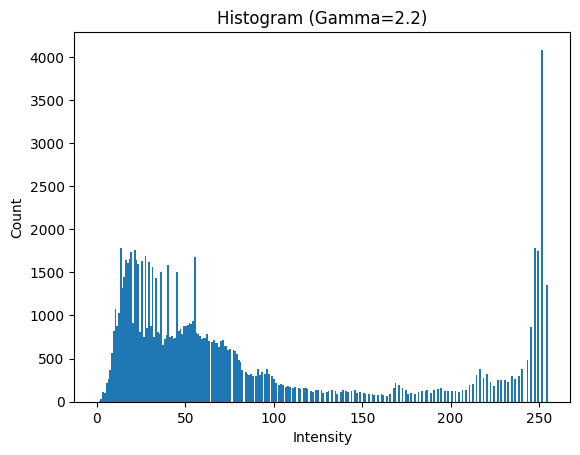

In [6]:
gamma_list: List[float] = (0.5, 1.0, 2.2)
for g in gamma_list:
    gimg = gamma_correction(img, gamma=g)
    plot_histogram(gimg, f"Histogram (Gamma={g})")

##### Canny edge

In [7]:
def canny_edges(
    img: np.ndarray,
    low_th: int,
    high_th: int,
    aperture_size: int = 3,
    L2gradient: bool = False,
) -> np.ndarray:
    assert aperture_size in (3, 5, 7)
    return cv2.Canny(img, low_th, high_th, apertureSize=aperture_size, L2gradient=L2gradient)

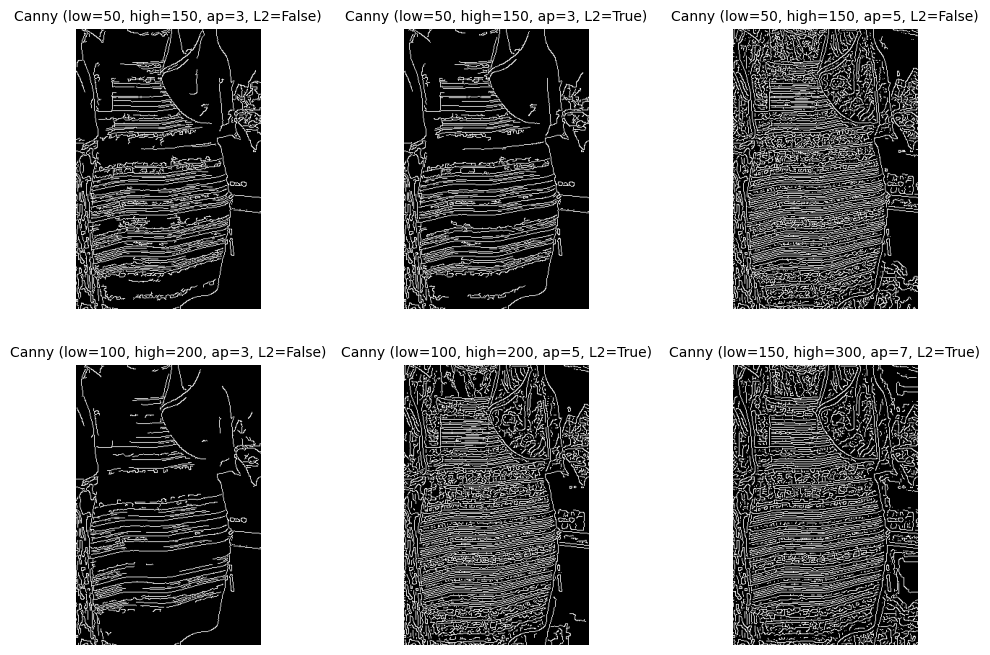

In [8]:
param_sets = [
        # (low, high, aperture, L2)
        (50, 150, 3, False),
        (50, 150, 3, True),
        (50, 150, 5, False),
        (100, 200, 3, False),
        (100, 200, 5, True),
        (150, 300, 7, True),
    ]


edges=[]
for i, (lo, hi, ap, l2) in enumerate(param_sets, 1):
    edge = canny_edges(img, lo, hi, ap, l2)
    edges.append(edge)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, edge, title in zip(axes.ravel(), edges, param_sets):
    ax.imshow(edge, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Canny (low={title[0]}, high={title[1]}, ap={title[2]}, L2={title[3]})", fontsize=10)
    ax.axis("off")

##### Sobel edge

In [9]:
def sobel_magnitude(img: np.ndarray, ksize: int = 3) -> np.ndarray:
    gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=ksize)
    gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=ksize)
    mag = np.sqrt(gx * gx + gy * gy)
    mag_u8 = normalize_to_uint8(mag)
    return mag_u8


def sobel_binary(img: np.ndarray, ksize: int = 3, thresh: int = 100) -> np.ndarray:
    mag = sobel_magnitude(img, ksize=ksize)
    _, binary = cv2.threshold(mag, thresh, 255, cv2.THRESH_BINARY)
    return binary

In [10]:
def compare_two(img_a: np.ndarray, img_b: np.ndarray, title_a: str, title_b: str):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_a, cmap="gray", vmin=0, vmax=255)
    axes[0].set_title(title_a)
    axes[0].axis("off")
    axes[1].imshow(img_b, cmap="gray", vmin=0, vmax=255)
    axes[1].set_title(title_b)
    axes[1].axis("off")
    fig.suptitle("Comparison")
    plt.show()
    plt.close(fig)

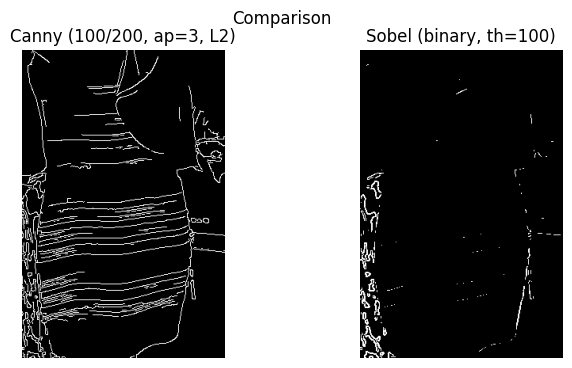

In [11]:
sobel_mag = sobel_magnitude(img, ksize=3)
sobel_bin = sobel_binary(img, ksize=3, thresh=100)

canny_rep = canny_edges(img, 100, 200, aperture_size=3, L2gradient=True)
compare_two(canny_rep, sobel_bin, "Canny (100/200, ap=3, L2)", "Sobel (binary, th=100)")